# M11.1 test — Hub Fourier model inference

Plan: [`plans/milestone_11/11_huggingface_artifacts_plan.md`](../../plans/milestone_11/11_huggingface_artifacts_plan.md) §B.

Downloads the published model [`tbhugging/singleview_cnn_fourier`](https://huggingface.co/tbhugging/singleview_cnn_fourier) and runs a forward pass on one packaged M8 demo `anomaly_ref` view at **180°** (same contract as Final Report M8 Step 3).

**Live Hub only:** always fetches from the remote repo (no Hugging Face cache fallback). Requires network; if the Hub is unreachable the download cell fails with an explicit error after a timeout. Example image comes from packaged `tomography_ml_validation` demo data (not the full M8 corpus).


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,hf,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path, install_display_safe_warning_paths

# Rewrite warning filenames (tqdm / huggingface_hub import paths) before Hub I/O.
install_display_safe_warning_paths()

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Download published weights from the Hub


In [2]:
from IPython.display import Markdown, display

from tomography_ml_validation.milestone_11 import (
    DEFAULT_HUB_DOWNLOAD_TIMEOUT_S,
    download_singleview_cnn_fourier,
    load_singleview_cnn_fourier,
    run_packaged_demo_inference,
)

HUB_ID = "tbhugging/singleview_cnn_fourier"
snap = download_singleview_cnn_fourier(
    hub_id=HUB_ID, timeout_s=DEFAULT_HUB_DOWNLOAD_TIMEOUT_S
)
loaded = load_singleview_cnn_fourier(snap, hub_id=HUB_ID)
display(Markdown(
    f"Loaded [`{loaded.hub_id}`](https://huggingface.co/{loaded.hub_id}) from "
    f"`{display_path(loaded.snapshot_dir)}`  \n"
    f"n_params={loaded.n_params}  "
    f"normalize=`{loaded.config.get('image_normalize')}`  "
    f"angle=`{loaded.config.get('keep_angles_deg')}`°"
))


Fetching 4 files: 100%|██████████| 4/4 [00:01<00:00,  2.84it/s]
venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loaded [`tbhugging/singleview_cnn_fourier`](https://huggingface.co/tbhugging/singleview_cnn_fourier) from `<temp>/gummybear_hub_jc7dq3j1`  
n_params=31811  normalize=`per_image_zscore`  angle=`180.0`°

## Inference on packaged demo anomaly @ 180°

Uses `bear_m8_high_000004` from the packaged M8 demo corpus (float `.raw.tif`, `per_image_zscore`).


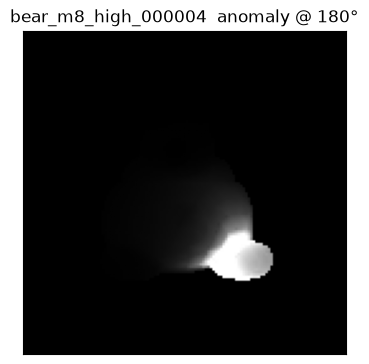

**pred xyz** = `(-7.1096, 1.8114, -3.3970)`  
**true xyz** = `(-8.3965, 1.5589, -3.3188)`  
**Euclidean error** = `1.3137`  
Image: `venv/lib/python3.12/site-packages/tomography_ml_validation/test_data/data/generated/m8_demo/bear_m8_high_000004/anomaly/bear_m8_high_000004_frame_0005_angle_+0180.00.raw.tif`

In [3]:
import numpy as np
import matplotlib.pyplot as plt

result = run_packaged_demo_inference(loaded)
sample = result.sample

fig, ax = plt.subplots(figsize=(4.2, 4.2))
img = np.asarray(sample.views_chw[0, 0], dtype=np.float32)
vmin, vmax = np.percentile(img, [1, 99])
ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
ax.set_title(f"{sample.sequence_id}  anomaly @ {sample.angle_deg:g}°")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

yp = result.y_pred
yt = result.y_true
display(Markdown(
    f"**pred xyz** = `({yp[0]:.4f}, {yp[1]:.4f}, {yp[2]:.4f})`  \n"
    f"**true xyz** = `({yt[0]:.4f}, {yt[1]:.4f}, {yt[2]:.4f})`  \n"
    f"**Euclidean error** = `{result.euclidean_error:.4f}`  \n"
    f"Image: `{display_path(sample.image_path)}`"
))


## Notes

- This notebook always downloads from the published Hub repo (no Hugging Face cache fallback). Offline mode, missing network, or a hung request fail with `HubDownloadError` after `DEFAULT_HUB_DOWNLOAD_TIMEOUT_S` (30 s).
- To load a local staging clone instead, use `load_singleview_cnn_fourier(<local-clone>)` from `11_1_singleview_cnn_fourier_export.ipynb` (not this notebook).
- Demo sequence is **not** from the full M8 train/val/test split; error magnitude is illustrative only.
